In [1]:
using BenchmarkTools
using Dates
using ProgressBars
using Distances

using Plots
using Plots.PlotMeasures
using StatsPlots, KernelDensity

include("../src/foldexity.jl")

### Test basic functions

In [ ]:
fxity, average_rmsd, num_clusts, norm_num_clusts, num_frags, matrix = fxpdb("../testpdb/d1914a1.pdb", 4, "seq", 1.0) 
fxity

In [ ]:
fxdir("../testpdb", "fxdata.tsv", 6, "knn", 1.0)
df = CSV.read("fxdata.tsv", DataFrame, delim = "\t")
rm("fxdata.tsv")
df

In [ ]:
fsize = 4
cutoff = 2

pdb = readpdb_backbone("../testpdb/d1914a1.pdb")
writepdb(pdb, "../testpdb/backbone.pdb")

xyzcoords = pdb2xyz(pdb)
xyzcoords = coords2kmers(xyzcoords, fsize)

pdbmatrix = pdb2pdbmatrix(pdb)
pdbfragments = coords2kmers(pdbmatrix, fsize)

fxity, average_rmsd, num_clusts, norm_num_clusts, num_frags, matrix = fxity_kabsh(xyzcoords)

pfrag1 = xyzcoords[10]
pfrag2 = xyzcoords[11]

kabsch_umeyama(pfrag1, pfrag2)

In [ ]:
nfrags = length(xyzcoords)  # Change this to the desired size
matrix = zeros(Float64, nfrags, nfrags)

for i = 1:nfrags # Fill the upper triangle
    for j = i+1:nfrags  # Ensure j >= i for the upper triangle
        matrix[i, j] = kabsch_umeyama(xyzcoords[i], xyzcoords[j])
    end
end

matrix += matrix' #make a symmetric matrix
aver_rmsd = sum(matrix) / (nfrags * nfrags)

cl = hclust(matrix, linkage=:complete)
results = cutree(cl, h=cutoff) 
nclusts = length(unique(results))
norm_nclusts = nclusts / nfrags

       

In [ ]:
# Perform hierarchical clustering
cl = hclust(matrix, linkage=:complete)

# Function to convert hclust to Newick format with matrix indices
function hclust_to_newick(cl::Hclust, labels::Vector{String})
    function build_tree(node)
        if node < 0  # leaf node
            index = -node
            return labels[index]  # Use label from the matrix
        else  # internal node
            left, right = cl.merge[node, :]
            left_tree = build_tree(left)
            right_tree = build_tree(right)
            return "($(left_tree):$(cl.height[node]),$(right_tree):$(cl.height[node]))"
        end
    end
    return build_tree(size(cl.merge, 1)) * ";"
end

# Define labels for each matrix point
labels = ["kmer_$i" for i in 1:size(matrix, 1)]

# Convert to Newick format with labels
newick_tree = hclust_to_newick(cl, labels)
println(newick_tree)

In [ ]:
function alphabet_heatmap(m, cmap)
    scale = 12
    i,j = size(m)
    h = heatmap(m, 
        color=cmap,  
        xlabel="Kmer1", ylabel="Kmer2", 
        grid=true, 
        #xticks=(1:10, 1:10:i), yticks=(1:j, 1:10:j), 
        
        size=([i,j] * scale),  
        margins = 5mm,
        dpi=500, yrotation = 90, tickfontsize=8)

    h = vline!(0.5:(j+0.5), c=:grey)
    h = hline!(0.5:(i+0.5), c=:grey, legend=false)
    #savefig("heatmap_3di_vs_AA.png")
    return h
end

morder = reverse(cl.order)
alphabet_heatmap(matrix[morder,morder], :bluesreds)

In [ ]:
fsize = 4
cutoff = 2
pdbfile = "../testpdb/d1914a1.pdb"

pdb = readpdb_calpha(pdbfile)
xyzcoords = pdb2xyz(pdb)
xyz4mers = coords2kmers(xyzcoords, fsize)

pdbmatrix = pdb2pdbmatrix(pdb)
pdbfragments = coords2kmers(pdbmatrix, fsize)

outdir =  split(basename(pdbfile), ".")[1]
if isdir(outdir)
    rm(outdir, force = true, recursive=true)
end

mkpath(outdir)
pdb = readpdb_calpha(pdbfile)
pdbfragments = coords2kmers(pdbmatrix, 4)
i = 1
for (cl, frag) in zip(results, pdbfragments)
    writepdb(pdbmatrix2pdb(frag), "$outdir/cl$(cl)frag$i.pdb")
    i+=1
end

### Complexity test

701

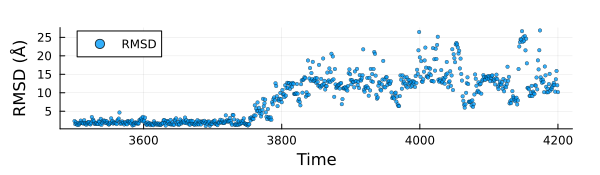

In [2]:
folding = "ubiq2"
folding_trajpdb = "../../mdfolding/pdbtraj_$folding"
rms = CSV.read("../../mdfolding/$folding.dat", DataFrame, header=["f", "d"], skipto=3)

b, e, o = 3500, 4200, 1

x = rms.d[b:o:e] 

print(length(x))

plot(b:o:e, x, seriestype = :scatter, 
size = (600, 175), markersize = 2, alpha = 0.8, margins = 5mm,
    label="RMSD", xlabel = "Time", ylabel="RMSD (Å)")


In [78]:
cpptraj("../../mdfolding/$folding.pdb", 
        "../../mdfolding/traj100_$folding.xtc", b, e, o,
        folding_trajpdb)

In [43]:
function rmsd_all_vs_all(vector1, vector2)        
    x = 2
    matrix = zeros(Float64, length(vector1), length(vector2))
    for i in 1:length(vector1)
        for j in 1:length(vector2)
                matrix[i,j] = rmsd(vector1[i], vector2[j])
                # matrix[matrix .< x] .= 0
                # matrix[matrix .> x] .= 1
                
        end
    end
    return matrix
end


function complexity(pdbpath)
    pdb = readpdb_calpha(pdbpath)
    xyzcoords = pdb2xyz(pdb)
    xyz4mers = coords2kmers(xyzcoords, 4)

    nscales = 6
    C = []
    for i in nscales+1:length(xyz4mers)-nscales-1

        s0 = i:i
        s1 = i-1:i+1
        s2 = i-2:i+2
        s3 = i-3:i+3
        s4 = i-4:i+4
        s5 = i-5:i+5
        s6 = i-6:i+6
        s7 = i-7:i+7
        s8 = i-8:i+8
        s9 = i-9:i+9
        s10 = i-10:i+10
        s11 = i-11:i+11
        s12 = i-12:i+12

        mr1 = sum(rmsd_all_vs_all(xyz4mers[s0], xyz4mers[s1]))
        mr2 = sum(rmsd_all_vs_all(xyz4mers[s1], xyz4mers[s2]))
        mr3 = sum(rmsd_all_vs_all(xyz4mers[s2], xyz4mers[s3]))
        mr4 = sum(rmsd_all_vs_all(xyz4mers[s3], xyz4mers[s4]))
        # mr5 = mean(rmsd_all_vs_all(xyz4mers[s4], xyz4mers[s5]))
        # mr6 = mean(rmsd_all_vs_all(xyz4mers[s5], xyz4mers[s6]))

        push!(C, mean([mr1, mr2, mr3, mr4]))
    end
    return C
end

pdbpath = "../testpdb/d1914a1.pdb"
C = complexity(pdbpath)
mean(C)


40.52001405424791

In [44]:
function cdir(dirpath)

    pdbpaths = []
    for (root, _, files) in walkdir(dirpath)
        for file in files
            push!(pdbpaths, joinpath(root, file))
        end
    end
    println("$(length(pdbpaths)) files are collected \nStarting foldexity...")
    
    complexities1 = []
    complexities2 = []

    #start loop with muptithreading
    Threads.@threads for pdbpath in ProgressBar(pdbpaths)
        try     
            c=complexity(pdbpath)
            push!(complexities1, sum(c))
            push!(complexities2, mean(c))
        catch 

        end

    end
    return complexities1, complexities2
end

(c1, c2)= cdir(folding_trajpdb)


701 files are collected 
Starting foldexity...


0.3%┣▏                                             ┫ 2/701 [00:00<00:30, 23it/s]
0.7%┣▎                                             ┫ 5/701 [00:00<00:35, 20it/s]
1.3%┣▋                                             ┫ 9/701 [00:00<00:30, 23it/s]
1.9%┣▉                                            ┫ 13/701 [00:00<00:28, 25it/s]
2.4%┣█                                            ┫ 17/701 [00:01<00:27, 25it/s]
3.0%┣█▍                                           ┫ 21/701 [00:01<00:27, 25it/s]
3.6%┣█▋                                           ┫ 25/701 [00:01<00:26, 26it/s]
4.1%┣█▉                                           ┫ 29/701 [00:01<00:26, 26it/s]
4.7%┣██▏                                          ┫ 33/701 [00:01<00:26, 26it/s]
5.3%┣██▍                                          ┫ 37/701 [00:01<00:26, 26it/s]
5.8%┣██▋                                          ┫ 41/701 [00:02<00:25, 26it/s]
6.4%┣██▉                                          ┫ 45/701 [00:02<00:25, 26it/s]
7.0%┣███▏                   

(Any[2964.412264424046, 3059.095056014188, 2814.8042535977806, 2902.7675751324086, 3002.891849368154, 2890.6539665097866, 2796.034365840889, 3041.3163084048315, 2653.123402796169, 3121.706458917509  …  2965.74314236941, 2686.7147145504996, 2857.000823914415, 3077.4105993083053, 2888.7390461737823, 2762.582139267694, 3085.8816386476115, 2840.392317842312, 2870.11396928885, 2893.7581069775347], Any[49.4068710737341, 50.984917600236464, 46.91340422662968, 48.37945958554015, 50.04819748946923, 48.17756610849644, 46.60057276401482, 50.688605140080526, 44.21872337993615, 52.02844098195848  …  49.429052372823506, 44.77857857584166, 47.616680398573585, 51.290176655138424, 48.14565076956304, 46.04303565446157, 51.431360644126855, 47.33987196403853, 47.83523282148084, 48.22930178295891])

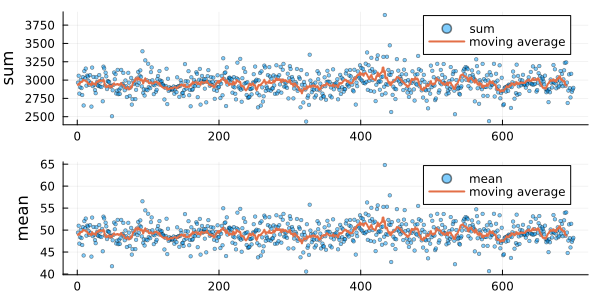

In [45]:
function pltdots(x, label, mk=2, alpha=.5, wsize=10)
    
    moving_average = [mean(x[i:i+wsize]) for i in 1:length(x)-wsize]

    p = plot(x, seriestype = :scatter, markersize = mk, alpha = alpha, label=label, ylabel=label)
    p = plot!(moving_average, linewidth = 2, alpha = 1, label="moving average")

    return p
end

p1 = pltdots(c1, "sum")
p2 = pltdots(c2, "mean")

plot(p1, p2, layout = (2,1), size = (600, 300))